In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/womens-shoe-prices/Datafiniti_Womens_Shoes.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")


In [3]:
data =  pd.read_csv('../input/womens-shoe-prices/Datafiniti_Womens_Shoes.csv')

In [4]:
data.shape 

(10000, 34)

In [5]:
data.head()

,id,dateAdded,dateUpdated,asins,brand,categories,primaryCategories,colors,dimension,ean,...,prices.merchant,prices.offer,prices.returnPolicy,prices.shipping,prices.size,prices.sourceURLs,sizes,sourceURLs,upc,weight
0,AVpfEf_hLJeJML431ueH,2015-05-04T12:13:08Z,2018-01-29T04:38:43Z,NaN,Naturalizer,"Clothing,Shoes,Women's Shoes,All Women's Shoes...",Shoes,"Silver,Cream Watercolor Floral",NaN,NaN,...,Overstock.com,NaN,NaN,NaN,S,https://www.overstock.com/Clothing-Shoes/Women...,"6W,9W,7.5W,12W,8.5M,9N,9M,9.5M,10.5M,10W,8.5W,...",https://www.walmart.com/ip/Naturalizer-Danya-W...,017136472311,NaN
1,AVpi74XfLJeJML43qZAc,2017-01-27T01:23:39Z,2018-01-03T05:21:54Z,NaN,MUK LUKS,"Clothing,Shoes,Women's Shoes,Women's Casual Sh...",Shoes,Grey,NaN,3.397705e+10,...,Walmart.com,NaN,NaN,Standard,6,https://www.walmart.com/ip/MUK-LUKS-Womens-Jan...,"10,7,6,9,8",https://www.walmart.com/ip/MUK-LUKS-Womens-Jan...,033977045743,NaN
2,AVpi74XfLJeJML43qZAc,2017-01-27T01:23:39Z,2018-01-03T05:21:54Z,NaN,MUK LUKS,"Clothing,Shoes,Women's Shoes,Women's Casual Sh...",Shoes,Grey,NaN,3.397705e+10,...,Slippers Dot Com,NaN,NaN,Value,6,https://www.walmart.com/ip/MUK-LUKS-Womens-Jan...,"10,7,6,9,8",https://www.walmart.com/ip/MUK-LUKS-Womens-Jan...,033977045743,NaN
3,AVpjXyCc1cnluZ0-V-Gj,2017-01-27T01:25:56Z,2018-01-04T11:52:35Z,NaN,MUK LUKS,"Clothing,Shoes,Women's Shoes,All Women's Shoes...","Shoes,Shoes",Black,6.0 in x 6.0 in x 1.0 in,3.397705e+10,...,Slippers Dot Com,NaN,NaN,Value,6,https://www.walmart.com/ip/MUK-LUKS-Womens-Daw...,"10,7,6,9,8",https://www.walmart.com/ip/MUK-LUKS-Womens-Daw...,033977045903,NaN
4,AVphGKLPilAPnD_x1Nrm,2017-01-27T01:25:56Z,2018-01-18T03:55:18Z,NaN,MUK LUKS,"Clothing,Shoes,Women's Shoes,All Women's Shoes...",Shoes,Grey,6.0 in x 6.0 in x 1.0 in,3.397705e+10,...,Walmart.com,NaN,NaN,Expedited,6,https://www.walmart.com/ip/MUK-LUKS-Womens-Daw...,"10,7,6,9,8",https://www.walmart.com/ip/MUK-LUKS-Womens-Daw...,033977045958,NaN


In [6]:
print('data_null:',data.isnull().sum())

data_null: id                         0
dateAdded                  0
dateUpdated                0
asins                   9997
brand                      0
categories                 0
primaryCategories          0
colors                  7369
dimension               9883
ean                     9329
imageURLs                  0
keys                       0
manufacturer            9473
manufacturerNumber      7518
name                       0
prices.amountMax           0
prices.amountMin           0
prices.availability     9566
prices.color               0
prices.condition        9562
prices.currency            0
prices.dateAdded         777
prices.dateSeen            0
prices.isSale              0
prices.merchant         9565
prices.offer            9879
prices.returnPolicy    10000
prices.shipping         9588
prices.size                0
prices.sourceURLs          0
sizes                      0
sourceURLs                 0
upc                      360
weight                  9701
dty

In [7]:
data.dtypes

id                      object
dateAdded               object
dateUpdated             object
asins                   object
brand                   object
categories              object
primaryCategories       object
colors                  object
dimension               object
ean                    float64
imageURLs               object
keys                    object
manufacturer            object
manufacturerNumber      object
name                    object
prices.amountMax       float64
prices.amountMin       float64
prices.availability     object
prices.color            object
prices.condition        object
prices.currency         object
prices.dateAdded        object
prices.dateSeen         object
prices.isSale             bool
prices.merchant         object
prices.offer            object
prices.returnPolicy    float64
prices.shipping         object
prices.size             object
prices.sourceURLs       object
sizes                   object
sourceURLs              object
upc     

In [8]:
#Xử lý dữ liệu
def preprocess_classification_data(df):
    # Chọn các cột cần thiết
    features = ['prices.amountMin', 'prices.amountMax', 'prices.condition', 
                'prices.currency', 'brand', 'categories', 'primaryCategories']
    df = df[features + ['prices.isSale']].dropna()
    
    # Chuyển đổi biến phân loại sang dạng số
    df = pd.get_dummies(df, columns=['prices.condition', 'prices.currency', 
                                      'brand', 'categories', 'primaryCategories'], drop_first=True)
    return df

# Xử lý dữ liệu
classification_data = preprocess_classification_data(data)

In [9]:
#Dự đoán khả năng giảm giá (Binary Classification)
#Tách tập huấn luyện và tập kiểm tra
# Tách dữ liệu thành đầu vào (X) và đầu ra (y)
X = classification_data.drop('prices.isSale', axis=1)
y = classification_data['prices.isSale']

# Tách thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Huấn luyện mô hình Random Forest
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [11]:
# Dự đoán và đánh giá
y_pred = classifier.predict(X_test)

# Độ chính xác và báo cáo phân loại
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.875
Classification Report:
               precision    recall  f1-score   support

       False       0.90      0.92      0.91        59
        True       0.82      0.79      0.81        29

    accuracy                           0.88        88
   macro avg       0.86      0.85      0.86        88
weighted avg       0.87      0.88      0.87        88



In [12]:
# Kiểm tra cột 'prices.dateSeen'
if 'prices.dateSeen' in data.columns:
    # Tách các giá trị trong cột 'prices.dateSeen' (phân cách bởi dấu phẩy)
    data['prices.dateSeen'] = data['prices.dateSeen'].str.split(',')
    
    # Lấy giá trị ngày đầu tiên trong danh sách (hoặc xử lý khác nếu cần)
    data['prices.dateSeen'] = data['prices.dateSeen'].apply(lambda x: x[0] if isinstance(x, list) else x)
    
    # Chuyển đổi sang định dạng datetime
    data['prices.dateSeen'] = pd.to_datetime(data['prices.dateSeen'], errors='coerce')
    
    # Loại bỏ các giá trị không hợp lệ (nếu có)
    data = data.dropna(subset=['prices.dateSeen'])
    
    # Lấy dữ liệu trong tuần gần đây nhất
    recent_data = data[data['prices.dateSeen'] >= data['prices.dateSeen'].max() - pd.Timedelta(days=7)]
else:
    # Nếu không có cột ngày, lấy ngẫu nhiên 5 dòng
    recent_data = data.sample(5, random_state=42)

# Xem dữ liệu gần đây
print(recent_data)

                       id             dateAdded           dateUpdated asins  \
165  AVpfKjuI1cnluZ0-fS-R  2016-11-04T03:10:53Z  2018-03-11T18:12:32Z   NaN   
169  AVpgn-k0LJeJML43Qjkj  2017-01-23T05:30:37Z  2018-03-12T00:45:13Z   NaN   

           brand                                         categories  \
165  ELLIE SHOES  Clothing,Shoes,Womens Shoes,Womens Oxford & Lo...   
169  Brinley Co.  Clothing,Shoes,Womens Shoes,Womens Comfort,Wom...   

    primaryCategories                              colors  \
165             Shoes  Pink,Black and Pink,Pink and White   
169             Shoes                                Grey   

                      dimension  ean  ... prices.merchant prices.offer  \
165                         NaN  NaN  ...   AmazingBasics          NaN   
169  11.0 in x 10.0 in x 5.0 in  NaN  ...     Walmart.com          NaN   

    prices.returnPolicy prices.shipping prices.size  \
165                 NaN           Value           6   
169                 NaN        

In [13]:
# Chuyển đổi cột `dateUpdated` sang kiểu datetime
data['dateUpdated'] = pd.to_datetime(data['dateUpdated'], errors='coerce')

# Lọc dữ liệu trong vòng 7 ngày gần nhất từ `dateUpdated`
recent_data = data[data['dateUpdated'] >= data['dateUpdated'].max() - pd.Timedelta(days=7)]

# Nếu dữ liệu nhỏ, chọn ngẫu nhiên 5 dòng
if recent_data.empty:
    recent_data = data.sample(5, random_state=42)

# Hiển thị dữ liệu gần đây
print(recent_data)

                        id             dateAdded               dateUpdated  \
167   AVpfDqWyLJeJML431bqP  2017-01-17T19:09:40Z 2018-03-17 06:14:34+00:00   
2416  AV2cZrmXglJLPUi8Ql2c  2017-08-01T06:06:04Z 2018-03-20 19:46:46+00:00   
2417  AV2cZrmXglJLPUi8Ql2c  2017-08-01T06:06:04Z 2018-03-20 19:46:46+00:00   
2418  AV2cZrmXglJLPUi8Ql2c  2017-08-01T06:06:04Z 2018-03-20 19:46:46+00:00   
2419  AV2cZrmXglJLPUi8Ql2c  2017-08-01T06:06:04Z 2018-03-20 19:46:46+00:00   
2420  AV2cZrmXglJLPUi8Ql2c  2017-08-01T06:06:04Z 2018-03-20 19:46:46+00:00   
2421  AV2cZrmXglJLPUi8Ql2c  2017-08-01T06:06:04Z 2018-03-20 19:46:46+00:00   

     asins        brand                                         categories  \
167    NaN  Brinley Co.  Clothing,Shoes,Womens Shoes,Womens Comfort,Wom...   
2416   NaN       Laredo  Clothing,Shoes,Women's Shoes,All Women's Shoes...   
2417   NaN       Laredo  Clothing,Shoes,Women's Shoes,All Women's Shoes...   
2418   NaN       Laredo  Clothing,Shoes,Women's Shoes,All Women

In [14]:
# Chọn các cột liên quan
next_week_data = recent_data[['prices.amountMin', 'prices.amountMax', 'prices.condition',
                              'prices.currency', 'brand', 'categories', 'primaryCategories']].copy()

# Xử lý dữ liệu: Loại bỏ các giá trị bị thiếu
next_week_data = next_week_data.dropna()

# Xử lý biến phân loại (dữ liệu cần phù hợp với mô hình đã huấn luyện)
def preprocess_input_data(df, training_columns):
    # One-hot encoding cho các cột phân loại
    df = pd.get_dummies(df, columns=['prices.condition', 'prices.currency', 'brand', 
                                      'categories', 'primaryCategories'], drop_first=True)
    # Đảm bảo trùng khớp với cột của tập huấn luyện
    missing_cols = set(training_columns) - set(df.columns)
    for col in missing_cols:
        df[col] = 0
    df = df[training_columns]
    return df

# Xử lý dữ liệu đầu vào cho mô hình
processed_data = preprocess_input_data(next_week_data, X_train.columns)  

In [15]:
# Dự đoán sản phẩm có khả năng giảm giá
predictions = classifier.predict(processed_data)

# Gắn kết quả dự đoán vào dữ liệu
next_week_data['prices.isSale (Predicted)'] = predictions

# Hiển thị kết quả
print("Dự đoán giảm giá trong 7 ngày tới:")
print(next_week_data)

Dự đoán giảm giá trong 7 ngày tới:
     prices.amountMin  prices.amountMax prices.condition prices.currency  \
167             30.88             39.99              New             USD   

           brand                                         categories  \
167  Brinley Co.  Clothing,Shoes,Womens Shoes,Womens Comfort,Wom...   

    primaryCategories  prices.isSale (Predicted)  
167             Shoes                       True  


In [16]:
# Xác định sản phẩm bán chạy nhất dựa trên số lần xuất hiện hoặc mức giá thấp nhất
most_sold_product = data.groupby('id')['prices.amountMin'].count().idxmax()

# Lọc dữ liệu của sản phẩm bán chạy nhất
most_sold_data = data[data['id'] == most_sold_product]

print("Thông tin sản phẩm bán chạy nhất:")
print(most_sold_data.head())

Thông tin sản phẩm bán chạy nhất:
                        id             dateAdded               dateUpdated  \
7965  AV46uYe4glJLPUi8VW57  2017-08-31T23:53:40Z 2018-02-01 07:34:21+00:00   
7966  AV46uYe4glJLPUi8VW57  2017-08-31T23:53:40Z 2018-02-01 07:34:21+00:00   
7967  AV46uYe4glJLPUi8VW57  2017-08-31T23:53:40Z 2018-02-01 07:34:21+00:00   
7968  AV46uYe4glJLPUi8VW57  2017-08-31T23:53:40Z 2018-02-01 07:34:21+00:00   
7969  AV46uYe4glJLPUi8VW57  2017-08-31T23:53:40Z 2018-02-01 07:34:21+00:00   

     asins brand                                         categories  \
7965   NaN  nike  Womens,Shoes,Athletic Shoes,Sneakers,Nike,Clot...   
7966   NaN  nike  Womens,Shoes,Athletic Shoes,Sneakers,Nike,Clot...   
7967   NaN  nike  Womens,Shoes,Athletic Shoes,Sneakers,Nike,Clot...   
7968   NaN  nike  Womens,Shoes,Athletic Shoes,Sneakers,Nike,Clot...   
7969   NaN  nike  Womens,Shoes,Athletic Shoes,Sneakers,Nike,Clot...   

     primaryCategories                                             col

In [17]:
# Lấy tên sản phẩm bán chạy nhất từ cột 'brand' và 'categories'
most_sold_product_name = most_sold_data[['brand', 'categories']].iloc[0]

# In tên sản phẩm
print("Tên sản phẩm bán chạy nhất:")
print(f"Thương hiệu: {most_sold_product_name['brand']}")
print(f"Danh mục: {most_sold_product_name['categories']}")

Tên sản phẩm bán chạy nhất:
Thương hiệu: nike
Danh mục: Womens,Shoes,Athletic Shoes,Sneakers,Nike,Clothing,Women's Shoes,Women's Casual Shoes,Women's Athletic Shoes


In [18]:
#Phân tích giá theo thời gian (Time Series Analysis)
#Xử lý dữ liệu chuỗi thời gian
def preprocess_time_series_data(df):
    # Chọn cột cần thiết
    time_series_data = df[['prices.dateSeen', 'prices.amountMin']].dropna()
    time_series_data['prices.dateSeen'] = pd.to_datetime(time_series_data['prices.dateSeen'])
    time_series_data = time_series_data.sort_values('prices.dateSeen')
    time_series_data.set_index('prices.dateSeen', inplace=True)
    return time_series_data

# Chuẩn bị dữ liệu chuỗi thời gian cho sản phẩm Nike
# Chuẩn bị dữ liệu chuỗi thời gian cho sản phẩm bán chạy nhất
nike_time_series = preprocess_time_series_data(most_sold_data)

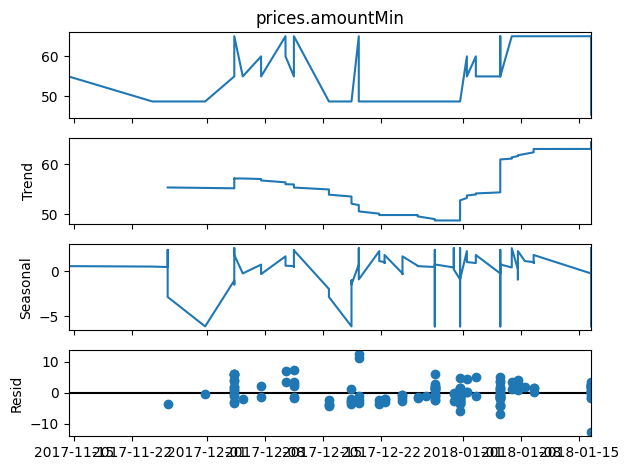

In [19]:
# Phân tích xu hướng và mùa vụ
result = seasonal_decompose(nike_time_series['prices.amountMin'], model='additive', period=30)
result.plot()
plt.show()

In [20]:
# Kiểm tra dữ liệu chuỗi thời gian
print("Dữ liệu chuỗi thời gian cho sản phẩm bán chạy nhất nike là:")
print(nike_time_series.head())


Dữ liệu chuỗi thời gian cho sản phẩm bán chạy nhất nike là:
                           prices.amountMin
prices.dateSeen                            
2017-11-14 07:50:00+00:00             59.99
2017-11-14 07:50:00+00:00             65.00
2017-11-14 07:50:00+00:00             54.99
2017-11-14 07:50:00+00:00             59.99
2017-11-14 07:50:00+00:00             54.99


In [21]:
# Huấn luyện mô hình ARIMA
model = ARIMA(nike_time_series['prices.amountMin'], order=(5, 1, 0))
arima_result = model.fit()

# In kết quả mô hình
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:       prices.amountMin   No. Observations:                  185
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -502.275
Date:                Thu, 26 Dec 2024   AIC                           1016.549
Time:                        10:49:01   BIC                           1035.839
Sample:                             0   HQIC                          1024.368
                                - 185                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6174      0.053    -11.667      0.000      -0.721      -0.514
ar.L2         -0.2087      0.074     -2.830      0.005      -0.353      -0.064
ar.L3         -0.1962      0.087     -2.258      0.0

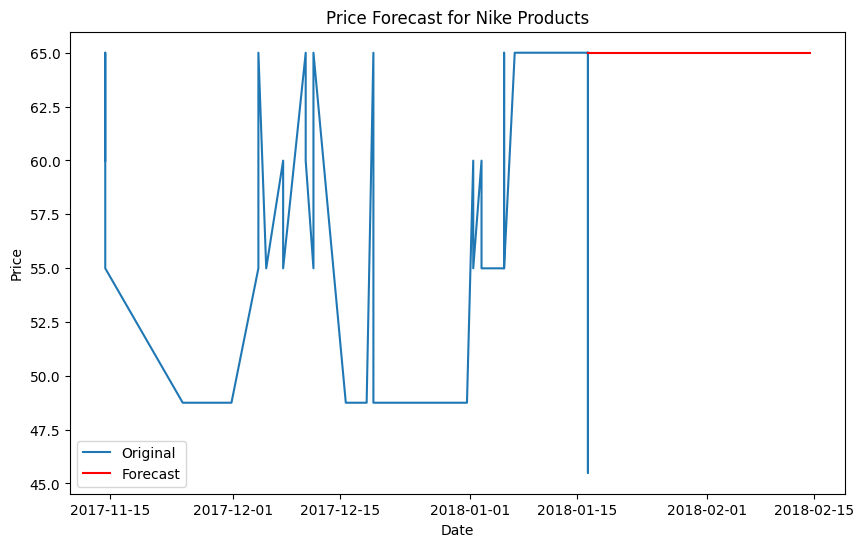

In [22]:
# Dự báo giá trong 30 ngày tới
forecast = arima_result.forecast(steps=30)

# Vẽ biểu đồ dự báo
plt.figure(figsize=(10, 6))
plt.plot(nike_time_series.index, nike_time_series['prices.amountMin'], label='Original')
plt.plot(pd.date_range(nike_time_series.index[-1], periods=30, freq='D'), forecast, label='Forecast', color='red')
plt.legend()
plt.title('Price Forecast for Nike Products')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()